In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def HistogramEqualize(img):
    
    h, w = img.shape

    hist = np.zeros(256, dtype=np.int32)
    for i in range(h):
        for j in range(w):
            hist[img[i, j]] += 1
 
    cdf = np.zeros(256, dtype=np.float32)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    cdf_hv = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_hv = np.round(cdf_hv).astype(np.uint8)
    
    equalized_img = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            equalized_img[i, j] = cdf_hv[img[i, j]]
    
    return equalized_img

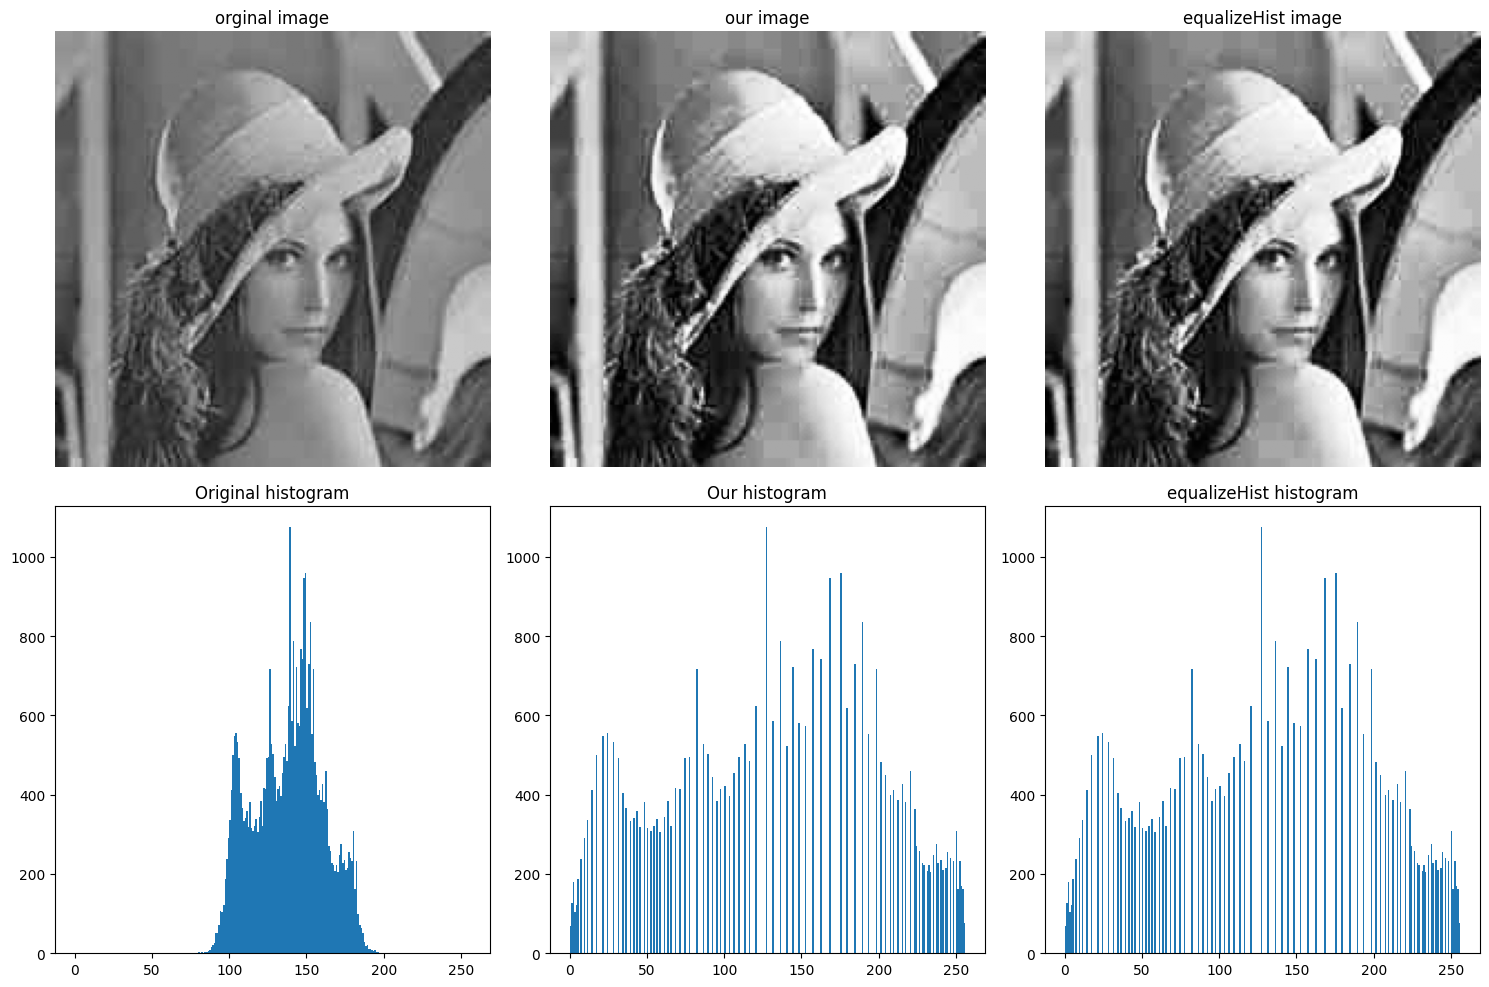

In [22]:
img = cv2.imread('1.jpg', cv2.IMREAD_GRAYSCALE)

ours = HistogramEqualize(img)
opencv = cv2.equalizeHist(img)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('orginal image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(ours, cmap='gray')
plt.title('our image')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(opencv, cmap='gray')
plt.title('equalizeHist image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(img.ravel(), 256, [0,256])
plt.title('Original histogram')

plt.subplot(2, 3, 5)
plt.hist(ours.ravel(), 256, [0,256])
plt.title('Our histogram')

plt.subplot(2, 3, 6)
plt.hist(opencv.ravel(), 256, [0,256])
plt.title('equalizeHist histogram')

plt.tight_layout()
plt.show()

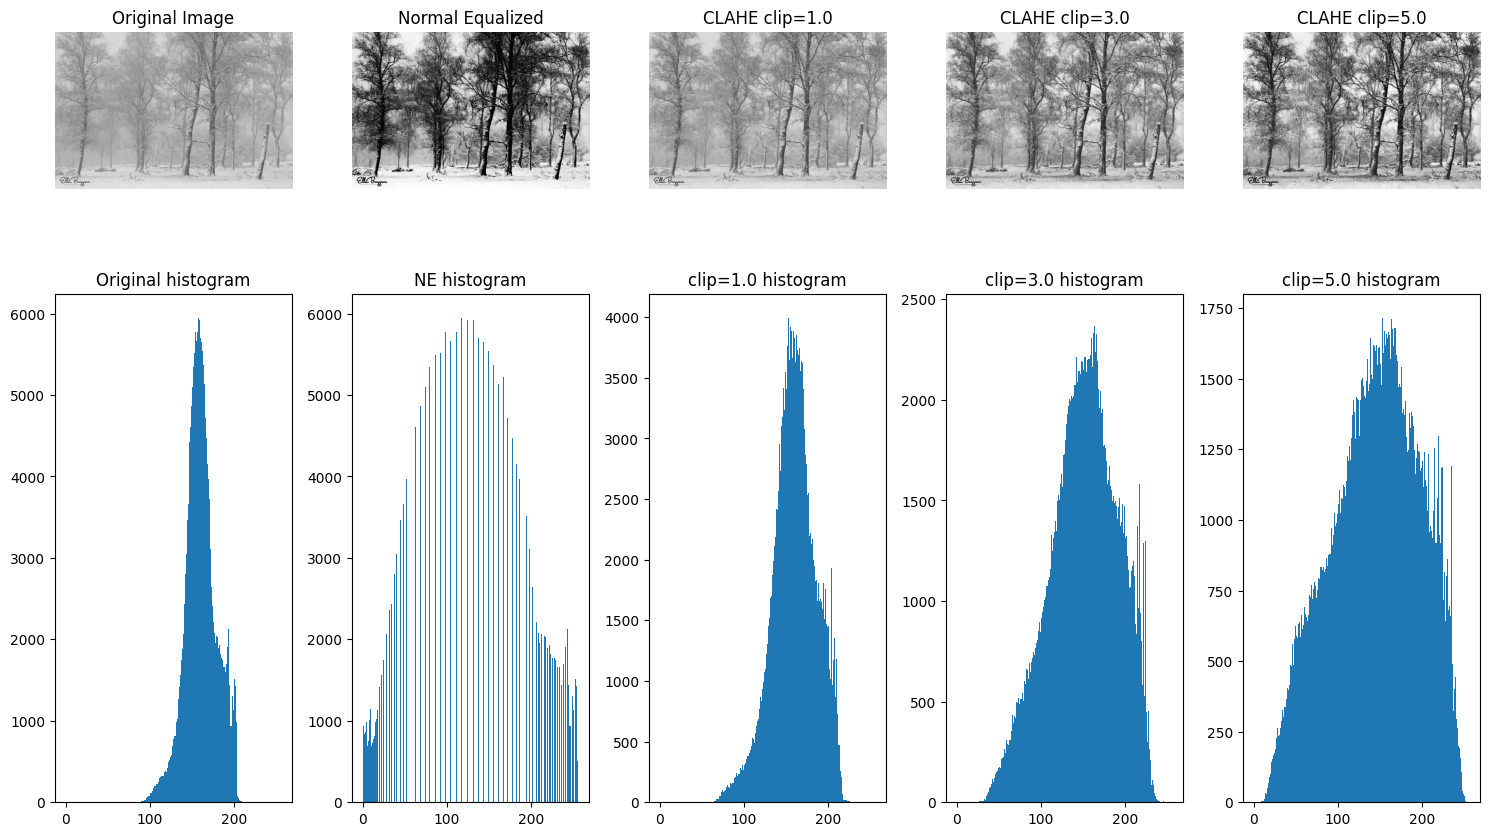

In [18]:
img = cv2.imread('2.jpg', cv2.IMREAD_GRAYSCALE)

clahe1 = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8,8))
clahe2 = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
clahe3 = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
    
result1 = clahe1.apply(img)
result2 = clahe2.apply(img)
result3 = clahe3.apply(img)
equalized = cv2.equalizeHist(img)
    
plt.figure(figsize=(15, 10))
    
plt.subplot(2, 5, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
    
plt.subplot(2, 5, 2)
plt.imshow(equalized, cmap='gray')
plt.title('Normal Equalized')
plt.axis('off')
    
plt.subplot(2, 5, 3)
plt.imshow(result1, cmap='gray')
plt.title('CLAHE clip=1.0')
plt.axis('off')
    
plt.subplot(2, 5, 4)
plt.imshow(result2, cmap='gray')
plt.title('CLAHE clip=3.0')
plt.axis('off')

plt.subplot(2, 5, 5)
plt.imshow(result3, cmap='gray')
plt.title('CLAHE clip=5.0')
plt.axis('off')


plt.subplot(2, 5, 6)
plt.hist(img.ravel(), 256, [0,256])
plt.title('Original histogram')

plt.subplot(2, 5, 7)
plt.hist(equalized.ravel(), 256, [0,256])
plt.title('NE histogram')

plt.subplot(2, 5, 8)
plt.hist(result1.ravel(), 256, [0,256])
plt.title('clip=1.0 histogram')

plt.subplot(2, 5, 9)
plt.hist(result2.ravel(), 256, [0,256])
plt.title('clip=3.0 histogram')

plt.subplot(2, 5, 10)
plt.hist(result3.ravel(), 256, [0,256])
plt.title('clip=5.0 histogram')
    
plt.tight_layout()
plt.show()

In [19]:
def local_enhance(img, window_size, C, K0, K1):

    img = img.astype(np.float32)
    h, w = img.shape
    pad = window_size // 2
    
    mG = np.mean(img)
    sigmaG = np.std(img)
    
    enhanced = np.zeros((h, w), dtype=np.float32)
    
    for i in range(h):
        for j in range(w):
            r1 = max(0, i - pad)
            r2 = min(h, i + pad + 1)
            c1 = max(0, j - pad)
            c2 = min(w, j + pad + 1)
            
            window = img[r1:r2, c1:c2]
            m_S = np.mean(window)
            sigma_S = np.std(window)
            
            if m_S <= K0 * mG and sigma_S <= K1 * sigmaG:
                enhanced[i, j] = C * img[i, j]
            else:
                enhanced[i, j] = img[i, j]
    
    enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)
    return enhanced

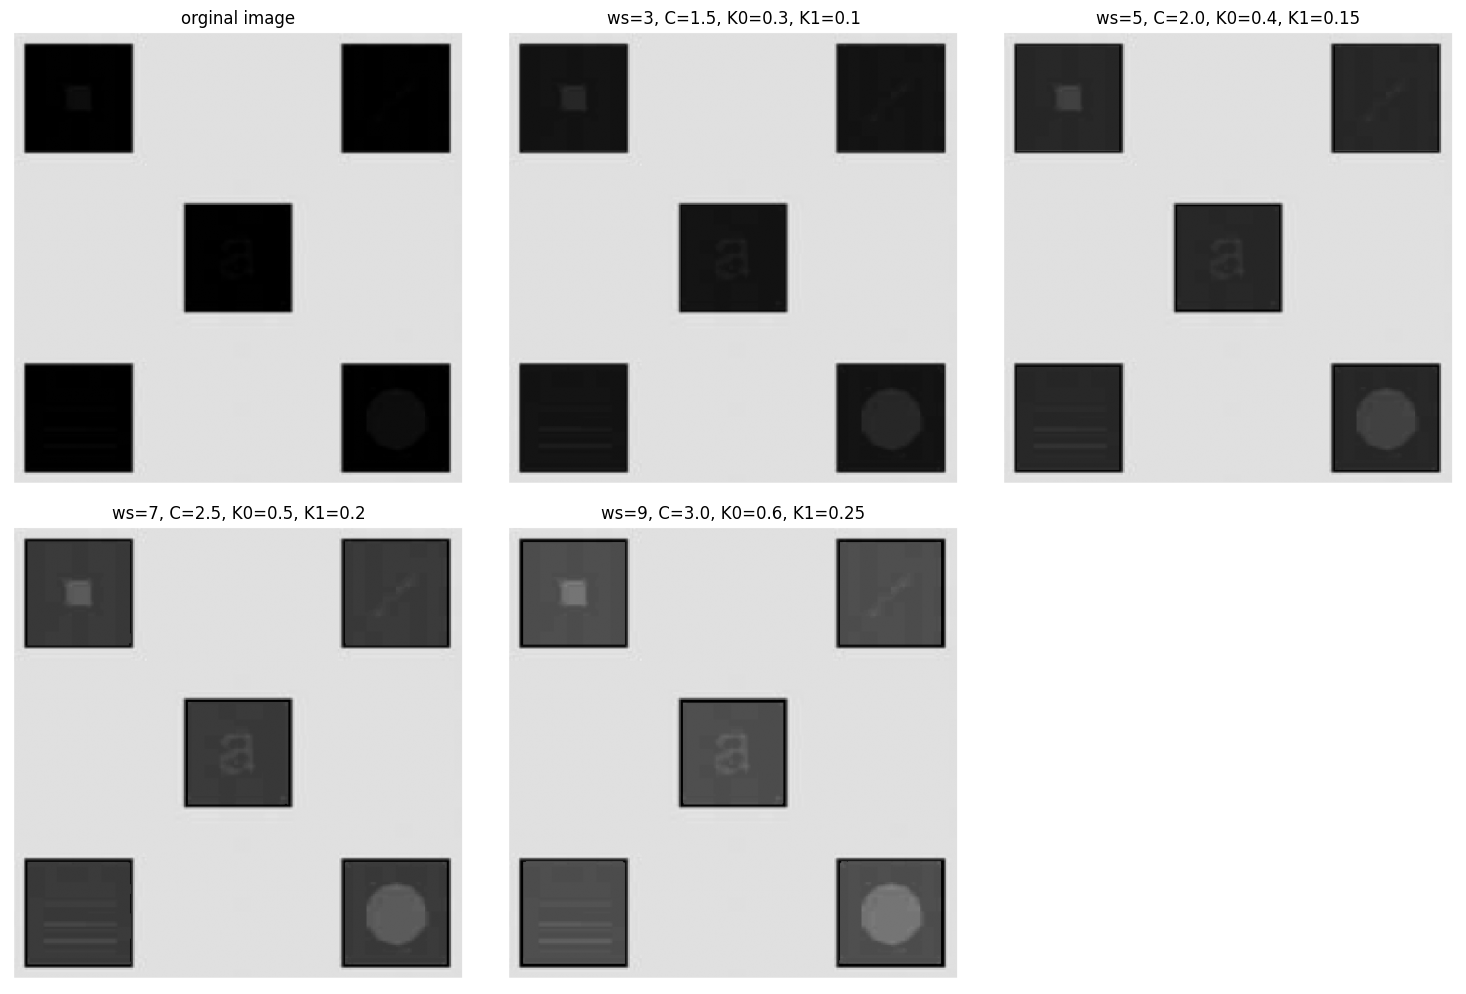

In [20]:
img = cv2.imread('fig3-27.jpg', cv2.IMREAD_GRAYSCALE)



parameters = [
    (3, 1.5, 0.3, 0.1),
    (5, 2.0, 0.4, 0.15),
    (7, 2.5, 0.5, 0.2),
    (9, 3.0, 0.6, 0.25)
]
    
plt.figure(figsize=(15, 15))
    
plt.subplot(3, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('orginal image')
plt.axis('off')
    
for idx, (ws, C, K0, K1) in enumerate(parameters, 2):
    result = local_enhance(img, ws, C, K0, K1)
    plt.subplot(3, 3, idx)
    plt.imshow(result, cmap='gray')
    plt.title(f'ws={ws}, C={C}, K0={K0}, K1={K1}')
    plt.axis('off')
    
plt.tight_layout()
plt.show()